In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from scipy import stats

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from matplotlib.ticker import FuncFormatter

In [2]:
rf_data = pd.read_csv("RF_prediction.csv")
rf_data['observationTime'] = pd.to_datetime(rf_data['observationTime'])
rf_data.head()

,observationTime,rf_prediction,actual,ECMWF
0,2024-02-02,4.749,0.5,6.074154
1,2024-02-03,1.195,3.4,2.074088
2,2024-02-04,3.381,6.5,3.847310
3,2024-02-05,3.576,6.2,4.799108
4,2024-02-06,8.456,2.8,8.335825


In [3]:
xgb_data = pd.read_csv("xgboost_pred.csv")
xgb_data['observationTime'] = pd.to_datetime(xgb_data['observationTime'])
xgb_data.head()

,observationTime,actual,xgb_predicted
0,2018-07-12,0.3,1.238406
1,2018-07-13,24.0,22.250040
2,2018-07-14,13.3,15.661434
3,2018-07-15,11.1,10.932304
4,2018-07-16,4.8,2.656915


In [4]:
ssa_lstm_data = pd.read_csv("SSA-LSTM_pred.csv")
ssa_lstm_data['observationTime'] = pd.to_datetime(ssa_lstm_data['observationTime'])
ssa_lstm_data.head()

,Unnamed: 0,observationTime,actual,SSA-LSTM
0,0,2024-08-11,2.1,1.472426
1,1,2024-08-12,0.0,0.554962
2,2,2024-08-13,0.0,0.872356
3,3,2024-08-14,0.0,0.000000
4,4,2024-08-15,0.0,0.556319


In [5]:
data_full = rf_data.merge(xgb_data[['observationTime', 'xgb_predicted']], on='observationTime', how='left')
data_full = data_full.merge(ssa_lstm_data[['observationTime', 'SSA-LSTM']], on='observationTime', how='left')
data_full.shape

(730, 6)

In [6]:
data_full.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM
0,2024-02-02,4.749,0.5,6.074154,5.147978,NaN
1,2024-02-03,1.195,3.4,2.074088,1.390713,NaN
2,2024-02-04,3.381,6.5,3.847310,3.099278,NaN
3,2024-02-05,3.576,6.2,4.799108,4.224149,NaN
4,2024-02-06,8.456,2.8,8.335825,7.595597,NaN


In [7]:
data_full_clean = data_full.dropna().copy()
data_full_clean.shape

(538, 6)

In [8]:
data_full_clean.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM
191,2024-08-11,1.297,2.1,1.924466,1.329129,1.472426
192,2024-08-12,1.232,0.0,0.910832,0.926465,0.554962
193,2024-08-13,1.286,0.0,1.111319,1.169705,0.872356
194,2024-08-14,0.000,0.0,0.000000,0.146910,0.000000
195,2024-08-15,0.000,0.0,0.000000,0.128554,0.556319


In [9]:
data_full_clean.to_csv('All_predictions.csv', index=False)

In [10]:
split_idx = int(len(data_full_clean) * 0.8)

train = data_full_clean.iloc[:split_idx].copy()
test  = data_full_clean.iloc[split_idx:].copy()

target = 'actual'
drop_cols = ['observationTime', target]

X_train = train.drop(columns=drop_cols)
y_train = train[target]
X_test = test.drop(columns=drop_cols)
y_test = test[target]

In [11]:
X_train.head()

,rf_prediction,ECMWF,xgb_predicted,SSA-LSTM
191,1.297,1.924466,1.329129,1.472426
192,1.232,0.910832,0.926465,0.554962
193,1.286,1.111319,1.169705,0.872356
194,0.000,0.000000,0.146910,0.000000
195,0.000,0.000000,0.128554,0.556319


In [12]:
pradzia = train['observationTime'].min()
pabaiga = train['observationTime'].max()

print(f"Mokymo aibė nuo {pradzia} iki {pabaiga} (dydis: {train.shape})")

Mokymo aibė nuo 2024-08-11 00:00:00 iki 2025-10-14 00:00:00 (dydis: (430, 6))


In [13]:
pradzia = test['observationTime'].min()
pabaiga = test['observationTime'].max()

print(f"Testavimo aibė nuo {pradzia} iki {pabaiga} (dydis: {test.shape})")

Testavimo aibė nuo 2025-10-15 00:00:00 iki 2026-01-30 00:00:00 (dydis: (108, 6))


In [14]:
dt_mdl = DecisionTreeRegressor(random_state=123)
dt_mdl.fit(X_train, y_train)
new_pred_dt_mdl = dt_mdl.predict(X_test)

In [15]:
rf_mdl = RandomForestRegressor(random_state=123)
rf_mdl.fit(X_train, y_train)
new_pred_rf_mdl = rf_mdl.predict(X_test)

In [16]:
xgb_mdl = XGBRegressor(random_state=123)
xgb_mdl.fit(X_train, y_train)
new_pred_xgb_mdl = xgb_mdl.predict(X_test)

In [17]:
def metrics_fun(y_val_true, rf_pred_val):
    print(f'R^2:  {r2_score(y_val_true, rf_pred_val)}')
    print(f'MAE:  {mean_absolute_error(y_val_true, rf_pred_val)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_val_true, rf_pred_val))}')
    # print(f'MAPE: {mean_absolute_percentage_error(y_val_true, rf_pred_val)}')
    corr, p_value = stats.spearmanr(y_val_true, rf_pred_val)
    print(f"r_s:  {corr}")

Globalus

In [18]:
metrics_fun(y_test, X_test['ECMWF'])

R^2:  0.6347515712616136
MAE:  1.1437363613788245
RMSE: 2.45239614905015
r_s:  0.7762166354737723


DecisionTreeRegressor

In [19]:
metrics_fun(y_test, new_pred_dt_mdl)

R^2:  0.49344990817883816
MAE:  1.1474025048433067
RMSE: 2.8880695427491894
r_s:  0.7251692321252956


RandomForestRegressor

In [20]:
metrics_fun(y_test, new_pred_rf_mdl)

R^2:  0.6151726935777396
MAE:  1.021534203690862
RMSE: 2.5172676104845926
r_s:  0.7830595249499802


XGBRegressor

In [21]:
metrics_fun(y_test, new_pred_xgb_mdl)

R^2:  0.6638779576501246
MAE:  1.1172449121051093
RMSE: 2.3525829445562367
r_s:  0.6966110324620138


Geriausiai pasirodė XGBoost modelis, todėl toliau tobulinsime ir vertinsime jį

In [22]:
xgb_default_importances = xgb_mdl.feature_importances_
xgb_default_importances

array([0.06373784, 0.2576127 , 0.09982385, 0.57882553], dtype=float32)

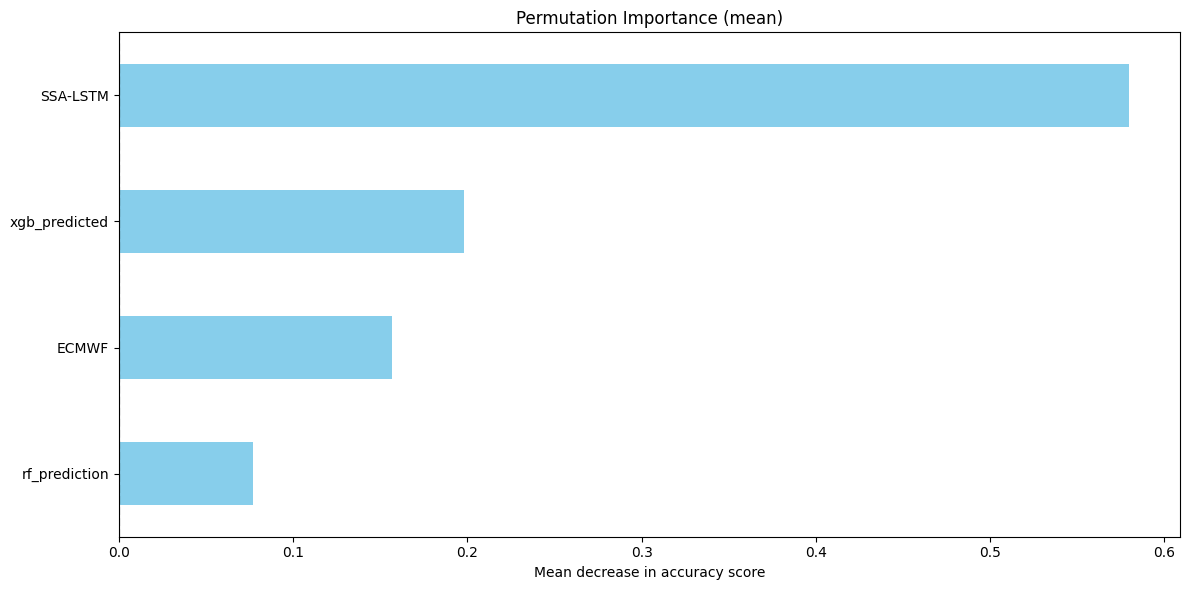

In [23]:
result = permutation_importance(xgb_mdl, X_test, y_test, n_repeats=5, random_state=123)
sorted_importances_idx = result.importances_mean.argsort()

importances_df = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_test.columns[sorted_importances_idx])

forest_importances = pd.Series(result.importances_mean, index=X_test.columns)
forest_importances = forest_importances[forest_importances > 0]
forest_importances = forest_importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
forest_importances.plot.barh(ax=ax, color='skyblue')
ax.set_title("Permutation Importance (mean)")
ax.set_xlabel("Mean decrease in accuracy score")
ax.axvline(x=0, color="k", linestyle="--")

fig.tight_layout()
plt.show()

---

In [ ]:
# param_grid = {
#     'n_estimators': [200, 300, 500, 600, 700],
#     'learning_rate': [0.005, 0.01, 0.05, 0.1],
#     'max_depth': [2, 3, 5],
#     'subsample': [0.8, 0.9, 1.0],
#     'min_split_loss':[14, 16, 20, 24, 28]
# }

# param_grid = {
#     'n_estimators': [300, 350, 380, 400, 450, 500, 550],
#     'learning_rate': [0.01, 0.03, 0.04, 0.05, 0.06, 0.07, 0.1, 0.15, 0.2],
#     'max_depth': [3, 4, 5, 6, 7, 8],
#     'subsample': [0.55, 0.58, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0],
#     'min_split_loss':[14, 15, 16, 17, 18, 19, 20,]
# }

# param_grid = {
#     'n_estimators': [550, 580, 590, 595, 598, 600, 603, 605, 607, 610, 615, 620],
#     'learning_rate': [0.04, 0.045, 0.05, 0.055, 0.06, 0.07, 0.08, 0.09, 0.1],
#     'max_depth': [4, 5, 6, 7, 8, 9, 10, 11, 12],
#     'subsample': [0.7, 0.73, 0.75, 0.78, 0.8, 0.83, 0.85, 0.9, 1.0],
#     'min_split_loss':[10, 12, 14, 16, 20, 24]
# }
# Geriausi parametrai: {'learning_rate': 0.05, 'max_depth': 5, 'min_split_loss': 16, 'n_estimators': 600, 'subsample': 0.8}

param_grid = {
    'n_estimators': [200, 350, 370, 300, 320, 350, 400],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.09, 0.1],
    'max_depth': [4, 5, 6, 7, 8, 9, 10],
    'subsample': [0.6, 0.7, 0.73, 0.75, 0.78, 0.8, 0.83, 0.85, 0.9, 1.0],
    'min_split_loss':[12, 14, 16, 20, 24, 28, 32]
}

tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(random_state=2026)

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=tscv, 
                           scoring='neg_root_mean_squared_error', verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_GS_model = grid_search.best_estimator_

print(f"Geriausi parametrai: {grid_search.best_params_}")

Fitting 3 folds for each of 20580 candidates, totalling 61740 fits
Geriausi parametrai: {'learning_rate': 0.1, 'max_depth': 4, 'min_split_loss': 24, 'n_estimators': 320, 'subsample': 0.85}


GS modelis - testavimo aibė

In [24]:
best_GS_xgb = XGBRegressor(n_estimators=320, max_depth=4, learning_rate=0.1, min_split_loss=24, subsample=0.85, random_state=2026)
best_GS_xgb.fit(X_train, y_train)
new_pred_best_xgb_mdl = best_GS_xgb.predict(X_test)
metrics_fun(y_test, new_pred_best_xgb_mdl)

R^2:  0.6742911344419755
MAE:  1.0925204896941423
RMSE: 2.315854324725173
r_s:  0.7720240782744016


In [25]:
new_pred_best_xgb_mdl.shape

(108,)

Default modelis - testavimo aibė

In [26]:
metrics_fun(y_test, new_pred_xgb_mdl)

R^2:  0.6638779576501246
MAE:  1.1172449121051093
RMSE: 2.3525829445562367
r_s:  0.6966110324620138


Globalus modelis - testavimo aibė

In [27]:
metrics_fun(y_test, X_test['ECMWF'])

R^2:  0.6347515712616136
MAE:  1.1437363613788245
RMSE: 2.45239614905015
r_s:  0.7762166354737723


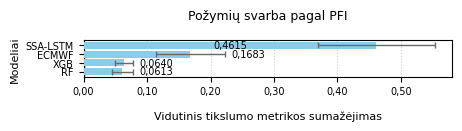

In [36]:
result = permutation_importance(best_GS_xgb, X_test, y_test, n_repeats=5, random_state=123)

importances_mean = pd.Series(result.importances_mean, index=X_test.columns)
importances_std = pd.Series(result.importances_std, index=X_test.columns)

pavadinimu_zaidimas = {
    'xgb_predicted': 'XGB',
    'rf_prediction': 'RF'}

importances_mean.index = importances_mean.index.map(lambda x: pavadinimu_zaidimas.get(x, x))
importances_std.index = importances_std.index.map(lambda x: pavadinimu_zaidimas.get(x, x))

importances_mean = importances_mean.sort_values(ascending=True)
importances_std = importances_std.reindex(importances_mean.index)

width_inch =  12/ 2.54
height_inch = width_inch * 0.30

fig, ax = plt.subplots(figsize=(width_inch, height_inch))

bars = ax.barh(importances_mean.index, importances_mean.values, 
                xerr=importances_std.values, color='skyblue', zorder=3,
                error_kw={'ecolor': 'dimgray', 'elinewidth': 1, 'capsize': 2, 'zorder': 4})

ax.set_title("Požymių svarba pagal PFI", fontsize=9, pad=15)
ax.set_xlabel("Vidutinis tikslumo metrikos sumažėjimas", fontsize=8, labelpad=10)
ax.set_ylabel("Modeliai", fontsize=8)

ax.tick_params(axis='both', labelsize=7)
ax.axvline(x=0, color="k", linestyle="--", linewidth=1, zorder=2)
ax.grid(True, axis='x', linestyle=':', alpha=0.6, zorder=0)

labels_inside = [
    f"{val:.4f}".replace('.', ',') if model_name == 'SSA-LSTM' else "" 
    for model_name, val in importances_mean.items()]

ax.bar_label(bars, labels=labels_inside, label_type='center', color='black', fontsize=7, zorder=5)


labels_outside = [
    f"{val:.4f}".replace('.', ',') if model_name != 'SSA-LSTM' else "" 
    for model_name, val in importances_mean.items()]
ax.bar_label(bars, labels=labels_outside, label_type='edge', padding=5, fontsize=7, zorder=5)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}".replace('.', ',')))

ax.margins(x=0.05)
plt.savefig("ensemble_PFI.png", dpi=300, bbox_inches='tight')
plt.tight_layout() 
plt.show()

In [ ]:
# Geriausi parametrai: {'learning_rate': 0.1, 'max_depth': 4, 'min_split_loss': 24, 'n_estimators': 320, 'subsample': 0.85}
# R^2:  0.6742911344419755
# MAE:  1.0925204896941423
# RMSE: 2.315854324725173
# r_s:  0.7720240782744016

# Geriausi parametrai: {'learning_rate': 0.1, 'max_depth': 4, 'min_split_loss': 24, 'n_estimators': 300, 'subsample': 0.85}
# R^2:  0.674441013992008
# MAE:  1.0940037508654568
# RMSE: 2.3153214268205056
# r_s:  0.7720240782744016

# Geriausi parametrai: {'learning_rate': 0.05, 'max_depth': 5, 'min_split_loss': 16, 'n_estimators': 600, 'subsample': 0.8}
# R^2:  0.6550698374041237
# MAE:  1.0678694661969583
# RMSE: 2.38320847105244
# r_s:  0.7903219843801592

# Geriausi parametrai: {'learning_rate': 0.05, 'max_depth': 6, 'min_split_loss': 20, 'n_estimators': 600, 'subsample': 0.8}
# R^2:  0.6537005138326849
# MAE:  1.0925816597610907
# RMSE: 2.3879342844338276
# r_s:  0.7778852331950346

# Geriausi parametrai: {'learning_rate': 0.09, 'max_depth': 6, 'min_split_loss': 14, 'n_estimators': 610, 'subsample': 0.75}
# R^2:  0.6537005138326849
# MAE:  1.0925816597610907
# RMSE: 2.3879342844338276
# r_s:  0.7778852331950346

# Geriausi parametrai: {'learning_rate': 0.08, 'max_depth': 8, 'min_split_loss': 12, 'n_estimators': 590, 'subsample': 0.78}
# R^2:  0.63580188185373
# MAE:  1.121718816913187
# RMSE: 2.4488675479032738
# r_s:  0.7915973024622709

# Geriausi parametrai: {'learning_rate': 0.08, 'max_depth': 8, 'min_split_loss': 12, 'n_estimators': 590, 'subsample': 0.78}
# R^2:  0.63580188185373
# MAE:  1.121718816913187
# RMSE: 2.4488675479032738
# r_s:  0.7915973024622709

# Geriausi parametrai: {'learning_rate': 0.1, 'max_depth': 7, 'min_split_loss': 19, 'n_estimators': 500, 'subsample': 0.65}
# R^2:  0.6534479668904198
# MAE:  1.1151539692849115
# RMSE: 2.3888048540074784
# r_s:  0.7584635978662512

# Geriausi parametrai: {'learning_rate': 0.1, 'max_depth': 7, 'min_split_loss': 19, 'n_estimators': 400, 'subsample': 0.65}
# R^2:  0.6568331090109674
# MAE:  1.1071490399664394
# RMSE: 2.377109224755416
# r_s:  0.7590317549150273

# Geriausi parametrai: {'learning_rate': 0.1, 'max_depth': 7, 'min_split_loss': 19, 'n_estimators': 350, 'subsample': 0.65}
# R^2:  0.6638779576501246
# MAE:  1.1172449121051093
# RMSE: 2.3525829445562367
# r_s:  0.6966110324620138

# Geriausi parametrai: {'learning_rate': 0.1, 'max_depth': 7, 'min_split_loss': 19, 'n_estimators': 350, 'subsample': 0.65}
# R^2:  0.6645324857999706
# MAE:  1.1087533061552022
# RMSE: 2.3502912440357813
# r_s:  0.7590995167648813

In [29]:
data_full_final = test.copy()
data_full_final['ensemble_xgb_pred'] = new_pred_best_xgb_mdl
data_full_final.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM,ensemble_xgb_pred
621,2025-10-15,0.644,0.6,0.503381,0.384646,0.000000,0.206881
622,2025-10-16,1.547,1.5,2.391799,1.467094,1.035582,1.029569
623,2025-10-17,2.691,8.5,2.918788,2.005413,6.982749,3.335974
624,2025-10-18,12.027,10.1,11.203026,11.060117,9.472771,8.474938
625,2025-10-19,0.090,0.0,0.000000,0.187164,0.021292,0.206881


In [30]:
data_full_final = data_full_final.dropna() 
data_full_final.shape

(108, 7)

In [31]:
data_full_final.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM,ensemble_xgb_pred
621,2025-10-15,0.644,0.6,0.503381,0.384646,0.000000,0.206881
622,2025-10-16,1.547,1.5,2.391799,1.467094,1.035582,1.029569
623,2025-10-17,2.691,8.5,2.918788,2.005413,6.982749,3.335974
624,2025-10-18,12.027,10.1,11.203026,11.060117,9.472771,8.474938
625,2025-10-19,0.090,0.0,0.000000,0.187164,0.021292,0.206881


In [32]:
data_full_final.to_csv('All_with_ensemble.csv', index=False)

---

Kryžminė patikra

In [33]:
from sklearn.model_selection import cross_val_score

In [34]:
tscv = TimeSeriesSplit(n_splits=5)
XGB_default_model = XGBRegressor(random_state=2026)

X = data_full_clean[['ECMWF', 'rf_prediction', 'xgb_predicted', 'SSA-LSTM']]
y = data_full_clean['actual']

score_mse  = cross_val_score(XGB_default_model, X, y, cv=tscv, scoring="neg_mean_squared_error")
score_mae  = cross_val_score(XGB_default_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
score_r2   = cross_val_score(XGB_default_model, X, y, cv=tscv, scoring="r2")

RMSE_scores = np.sqrt(np.abs(score_mse))
MAE_scores  = np.abs(score_mae)
R2_scores   = score_r2

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Mean':   [round(MAE_scores.mean(), 4), round(RMSE_scores.mean(), 4), round(R2_scores.mean(), 4)],
    'Std':    [round(MAE_scores.std(),  4), round(RMSE_scores.std(),  4), round(R2_scores.std(),  4)]
})

print(results.to_string(index=False))

Metric   Mean    Std
   MAE 1.3213 0.8362
  RMSE 2.5060 1.3812
    R2 0.3523 0.2826


In [35]:
tscv = TimeSeriesSplit(n_splits=5)
XGB_best_model = XGBRegressor(n_estimators=320, max_depth=4, learning_rate=0.1, min_split_loss=24, subsample=0.85, random_state=2026)

X = data_full_clean[['ECMWF', 'rf_prediction', 'xgb_predicted', 'SSA-LSTM']]
y = data_full_clean['actual']

score_mse  = cross_val_score(XGB_best_model, X, y, cv=tscv, scoring="neg_mean_squared_error")
score_mae  = cross_val_score(XGB_best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
score_r2   = cross_val_score(XGB_best_model, X, y, cv=tscv, scoring="r2")

RMSE_scores = np.sqrt(np.abs(score_mse))
MAE_scores  = np.abs(score_mae)
R2_scores   = score_r2

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Mean':   [round(MAE_scores.mean(), 4), round(RMSE_scores.mean(), 4), round(R2_scores.mean(), 4)],
    'Std':    [round(MAE_scores.std(),  4), round(RMSE_scores.std(),  4), round(R2_scores.std(),  4)]
})

print(results.to_string(index=False))

Metric   Mean    Std
   MAE 1.2090 0.7075
  RMSE 2.3165 1.4367
    R2 0.5311 0.0908
